### 1. Load the dataset

In [482]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [483]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [484]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [485]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    print(f"{col}")
    print(df[col].describe())
    print()

Year
count    11914.000000
mean      2010.384338
std          7.579740
min       1990.000000
25%       2007.000000
50%       2015.000000
75%       2016.000000
max       2017.000000
Name: Year, dtype: float64

Engine HP
count    11845.00000
mean       249.38607
std        109.19187
min         55.00000
25%        170.00000
50%        227.00000
75%        300.00000
max       1001.00000
Name: Engine HP, dtype: float64

Engine Cylinders
count    11884.000000
mean         5.628829
std          1.780559
min          0.000000
25%          4.000000
50%          6.000000
75%          6.000000
max         16.000000
Name: Engine Cylinders, dtype: float64

Number of Doors
count    11908.000000
mean         3.436093
std          0.881315
min          2.000000
25%          2.000000
50%          4.000000
75%          4.000000
max          4.000000
Name: Number of Doors, dtype: float64

highway MPG
count    11914.000000
mean        26.637485
std          8.863001
min         12.000000
25%         22.0

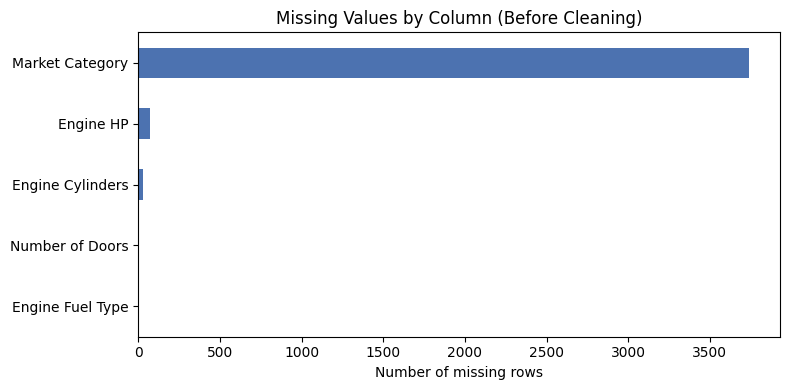

In [486]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(kind="barh", figsize=(8,4), color="#4C72B0")
plt.xlabel("Number of missing rows")
plt.title("Missing Values by Column (Before Cleaning)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 2. Standardize Column Names
Snake_case is easier to work with downstream (e.g. `Engine HP` -> `engine_hp`).

In [487]:
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_")
    .str.replace("__", "_")
    .str.lower()
)
df.columns.tolist()

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity',
 'msrp']

### 3. Remove Duplicates

In [488]:
n_before = len(df)
dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print(f"Removed {dupes} duplicate rows: {n_before} -> {len(df)}")

Removed 715 duplicate rows: 11914 -> 11199


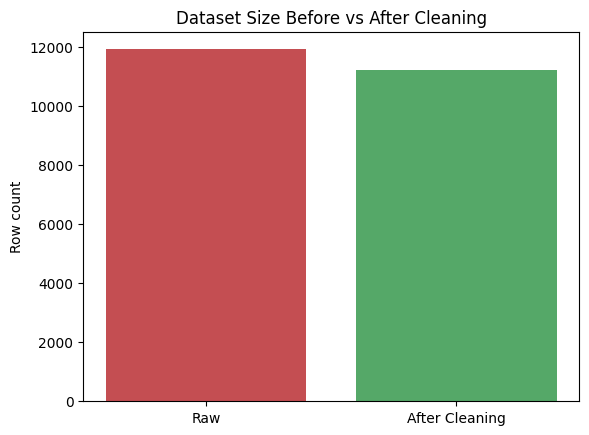

In [489]:
plt.bar(["Raw", "After Cleaning"], [n_before, len(df)], color=["#C44E52", "#55A868"])
plt.ylabel("Row count")
plt.title("Dataset Size Before vs After Cleaning")
plt.show()

### 4. Missing Values


**4a. `engine_fuel_type`** : only 3 missing.

In [490]:
mode_fuel = df["engine_fuel_type"].mode()[0]
df["engine_fuel_type"] = df["engine_fuel_type"].fillna(mode_fuel)

print(df["engine_fuel_type"].isnull().sum())

0


**4b. `engine_hp`** : 69 missing.

In [491]:
import warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")

df["engine_hp"] = df.groupby(["make", "model"], observed=True)["engine_hp"].transform(lambda x: x.fillna(x.median()))
df["engine_hp"] = df["engine_hp"].fillna(df["engine_hp"].median())

print(df["engine_hp"].isnull().sum())

0


**4c. `engine_cylinders`** : 30 missing.

In [492]:
is_electric = df["engine_fuel_type"].str.contains("electric", case=False, na=False)
df.loc[is_electric & df["engine_cylinders"].isnull(), "engine_cylinders"] = 0

df["engine_cylinders"] = df.groupby(["make", "model"], observed=True)["engine_cylinders"].transform(lambda x: x.fillna(x.median()))
df["engine_cylinders"] = df["engine_cylinders"].fillna(df["engine_cylinders"].median())

print(df["engine_cylinders"].isnull().sum())

0


**4d. `number_of_doors`** : 6 missing.

In [493]:
df["number_of_doors"] = df.groupby("vehicle_style")["number_of_doors"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
df["number_of_doors"] = df["number_of_doors"].fillna(df["number_of_doors"].mode()[0])

print(df["number_of_doors"].isnull().sum())

0


**4e. `market_category`** : 3,742 missing. 

In [494]:
df["market_category"] = df["market_category"].fillna("Unlabeled")

print(df["market_category"].isnull().sum())

0


**4f. `transmission_type`** : 12 missing. 

In [495]:
n_unknown = (df["transmission_type"] == "UNKNOWN").sum()
mode_transmission = df["transmission_type"].mode()[0]
df["transmission_type"] = df["transmission_type"].replace("UNKNOWN", mode_transmission)

print(f"Replaced {n_unknown} 'UNKNOWN' values in transmission_type with mode: {mode_transmission}")
print((df["transmission_type"] == "UNKNOWN").sum()) 


Replaced 12 'UNKNOWN' values in transmission_type with mode: AUTOMATIC
0


In [496]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
market_category      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

### 5. Fix Data Types

In [497]:
df["engine_cylinders"] = df["engine_cylinders"].astype(int)
df["number_of_doors"] = df["number_of_doors"].astype(int)

categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col] = df[col].astype("category")

df.dtypes

make                 category
model                category
year                    int64
engine_fuel_type     category
engine_hp             float64
engine_cylinders        int64
transmission_type    category
driven_wheels        category
number_of_doors         int64
market_category      category
vehicle_size         category
vehicle_style        category
highway_mpg             int64
city_mpg                int64
popularity              int64
msrp                    int64
dtype: object

### 6. Outliers / Data Quality Flags


In [498]:
df["msrp"].value_counts().sort_values(ascending=False).head(10)

msrp
2000     748
29995     18
25995     17
20995     15
27995     15
24995     14
21995     14
30995     13
22995     12
23995     12
Name: count, dtype: int64

In [499]:
suspicious_price = df["msrp"] == 2000
df["price_flag_suspicious"] = suspicious_price

print(f"{suspicious_price.sum()} rows flagged as suspicious price (${2000})")

748 rows flagged as suspicious price ($2000)


In [500]:
high_price = df["msrp"] > df["msrp"].quantile(0.99)

print(f"99th percentile MSRP: ${df['msrp'].quantile(0.99):,.0f}")
print(f"Max MSRP: ${df['msrp'].max():,.0f}")

99th percentile MSRP: $290,009
Max MSRP: $2,065,902


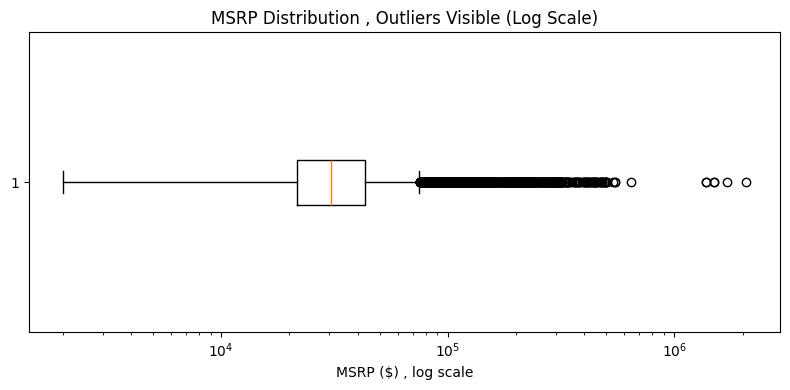

In [501]:
plt.figure(figsize=(8,4))
plt.boxplot(df["msrp"], vert=False)
plt.xscale("log")
plt.xlabel("MSRP ($) , log scale")
plt.title("MSRP Distribution , Outliers Visible (Log Scale)")
plt.tight_layout()
plt.show()

In [502]:
df[df["highway_mpg"] > 100][["make", "model", "year", "engine_fuel_type", "highway_mpg", "city_mpg"]]

,make,model,year,engine_fuel_type,highway_mpg,city_mpg
520,FIAT,500e,2015,electric,108,122
521,FIAT,500e,2016,electric,103,121
522,FIAT,500e,2017,electric,103,121
1083,Audi,A6,2017,premium unleaded (recommended),354,24
1865,Chevrolet,Bolt EV,2017,electric,110,128
1866,Chevrolet,Bolt EV,2017,electric,110,128
3507,Volkswagen,e-Golf,2015,electric,105,126
3508,Volkswagen,e-Golf,2015,electric,105,126
3509,Volkswagen,e-Golf,2016,electric,105,126
3510,Volkswagen,e-Golf,2016,electric,105,126


In [503]:
before_fix = df["highway_mpg"]

df.loc[(df["make"] == "Audi") & (df["model"] == "A6") & (df["highway_mpg"] == 354), "highway_mpg"] = np.nan
df["highway_mpg"] = df["highway_mpg"].fillna(df.groupby(["make", "model"], observed=True)["highway_mpg"].transform("median"))

print(df["highway_mpg"].max())

111.0


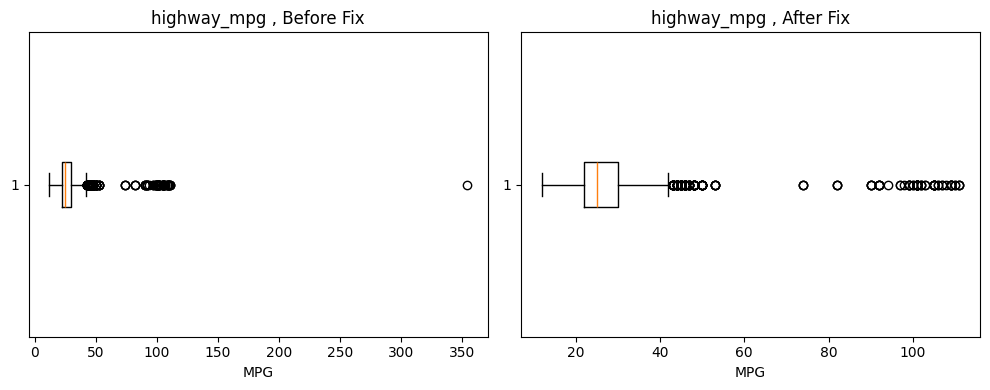

In [504]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].boxplot(before_fix, vert=False)
axes[0].set_title("highway_mpg , Before Fix")
axes[0].set_xlabel("MPG")

axes[1].boxplot(df["highway_mpg"], vert=False)
axes[1].set_title("highway_mpg , After Fix")
axes[1].set_xlabel("MPG")

plt.tight_layout()
plt.show()

### 7. Feature Engineering


In [505]:
df["car_age"] = df["year"].max() - df["year"]  # age relative to newest car in the dataset
df["is_electric"] = is_electric

df[["year", "car_age", "is_electric"]].head()

,year,car_age,is_electric
0,2011,6,False
1,2011,6,False
2,2011,6,False
3,2011,6,False
4,2011,6,False


In [506]:
df.to_csv("clean_data.csv", index=False)

print(f"Final shape: {df.shape}")

Final shape: (11199, 19)
